In [2]:
import sys
if '..' not in sys.path:
    sys.path.insert(0, '..')

import matplotlib.pyplot as plt
from core.utils import load_run_data
import jax.numpy as jnp

# Use a clean style
plt.style.use('seaborn-v0_8-paper') 

def smooth(data, window_size=20):
    """Computes a simple moving average for smoothing."""
    if window_size <= 1:
        return data
    kernel = jnp.ones(window_size) / window_size
    return jnp.convolve(data, kernel, mode='valid')

def plot_experiment(metrics, metric_keys, label, log=False):
    # We use the 'label' argument for the line legend
    for item in metric_keys:
        values = metrics[item]
        y = values.mean(0) if values.ndim > 1 else values
        y_smooth = smooth(y, window_size=10)
        plt.plot(y_smooth, label=label, linewidth=1.85, alpha = 0.9)
        if log:
            plt.yscale('log')

def plot_experiments(metrics_list, title, metric_keys, run_labels, log=False):
    plt.figure(figsize=(5, 5))
    plt.style.use('seaborn-v0_8-paper')
    
    # Iterate through both metrics and their corresponding labels
    for metrics, label in zip(metrics_list, run_labels):
        plot_experiment(metrics, metric_keys, label, log)
        
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel("Update", fontsize=12)
    plt.legend(frameon=True, loc='lower left')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

# Execution


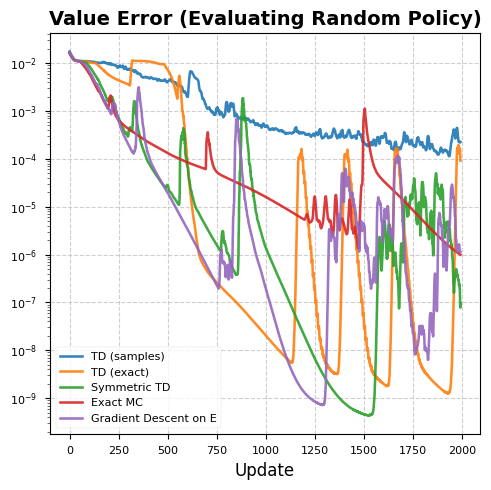

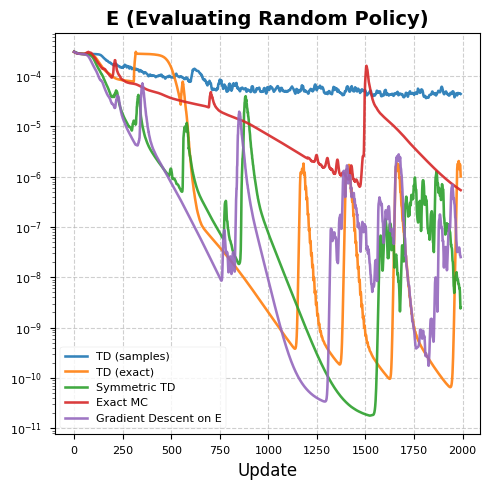

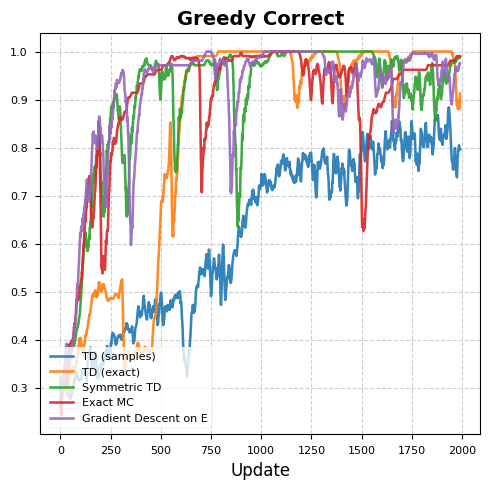

In [3]:
stochastic_td_config, stochastic_td_metrics = load_run_data("random_td/6_24", 'FourRooms-misc', 'results')
td_config, td_metrics = load_run_data("random_td_exact/6_24", 'FourRooms-misc', 'results')
s_td_config, s_td_metrics = load_run_data("random_td_exact_symmetric/6_24", 'FourRooms-misc', 'results')
mc_config, mc_metrics = load_run_data("random_mc_exact/6_24", 'FourRooms-misc', 'results')
e_config, e_metrics = load_run_data("random_exact_E/6_24", 'FourRooms-misc', 'results')

plot_experiments(
    metrics_list=[stochastic_td_metrics, td_metrics, s_td_metrics, mc_metrics, e_metrics],
    run_labels=["TD (samples)", "TD (exact)", "Symmetric TD", "Exact MC", "Gradient Descent on E"],
    metric_keys=['nn_weighted_VE'],
    title="Value Error (Evaluating Random Policy)",
    log = True
)

plot_experiments(
    metrics_list=[stochastic_td_metrics, td_metrics, s_td_metrics, mc_metrics, e_metrics],
    run_labels=["TD (samples)", "TD (exact)", "Symmetric TD", "Exact MC", "Gradient Descent on E"],
    title="E (Evaluating Random Policy)",
    metric_keys=['E'],
    log = True
)

plot_experiments(
    metrics_list=[stochastic_td_metrics, td_metrics, s_td_metrics, mc_metrics, e_metrics],
    run_labels=["TD (samples)", "TD (exact)", "Symmetric TD", "Exact MC", "Gradient Descent on E"],
    title="Greedy Correct",
    metric_keys=['nn_greedy_correct']
)

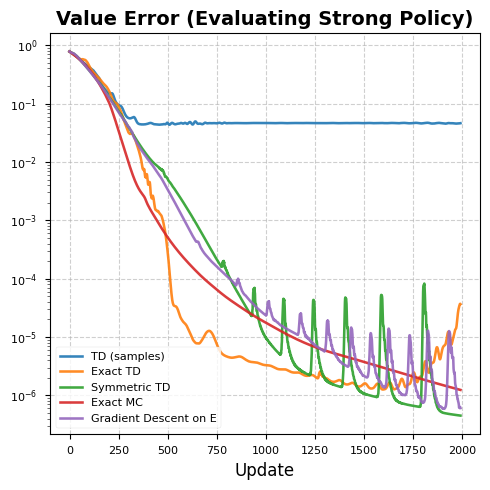

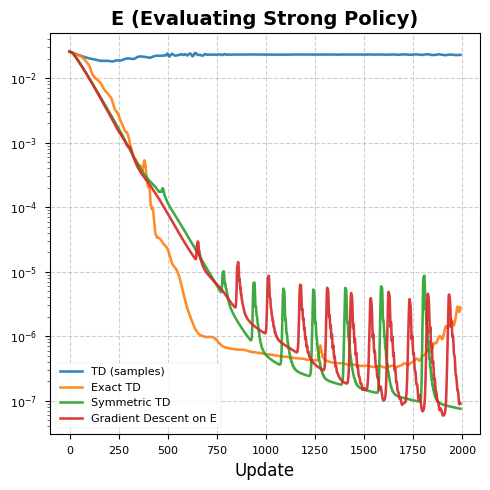

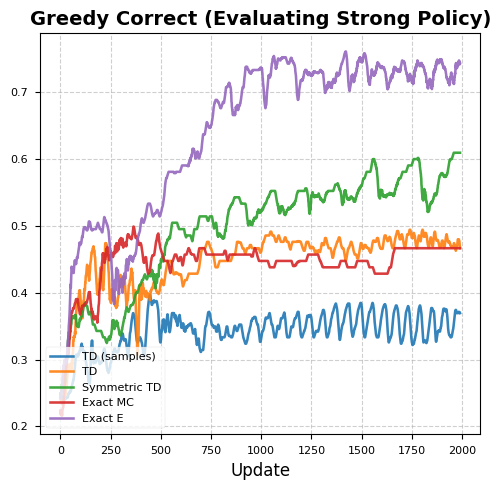

In [4]:
stochastic_td_config, stochastic_td_metrics = load_run_data("fixed_td/6_24", 'FourRooms-misc', 'results')
td_config, td_metrics = load_run_data("fixed_td_exact/6_24", 'FourRooms-misc', 'results')
s_td_config, s_td_metrics = load_run_data("fixed_td_exact_symmetric/6_24", 'FourRooms-misc', 'results')
mc_config, mc_metrics = load_run_data("fixed_mc_exact/6_24", 'FourRooms-misc', 'results')
e_config, e_metrics = load_run_data("fixed_E_gd_exact/6_24", 'FourRooms-misc', 'results')

plot_experiments(
    metrics_list=[stochastic_td_metrics, td_metrics, s_td_metrics, mc_metrics, e_metrics],
    run_labels=["TD (samples)", "Exact TD", "Symmetric TD", "Exact MC", "Gradient Descent on E"],
    title="Value Error (Evaluating Strong Policy)",
    metric_keys=['nn_weighted_VE'], log=True
)

plot_experiments(
    metrics_list=[stochastic_td_metrics, td_metrics, s_td_metrics, e_metrics],
    run_labels=["TD (samples)" , "Exact TD", "Symmetric TD", "Gradient Descent on E"],
    title="E (Evaluating Strong Policy)",
    metric_keys=['E'], log=True
)

# plot_experiments(
#     metrics_list=[stochastic_td_metrics, td_metrics, s_td_metrics, mc_metrics, e_metrics],
#     run_labels=["TD (samples)" , "TD"],
#     title="Alignment (Evaluating Strong Policy)",
#     metric_keys=['alignment_condition'], log=True
# )


plot_experiments(
    metrics_list=[stochastic_td_metrics, td_metrics, s_td_metrics, mc_metrics, e_metrics],
    run_labels=["TD (samples)", "TD", "Symmetric TD","Exact MC", "Exact E"],
    title="Greedy Correct (Evaluating Strong Policy)",
    metric_keys=['nn_greedy_correct']
)

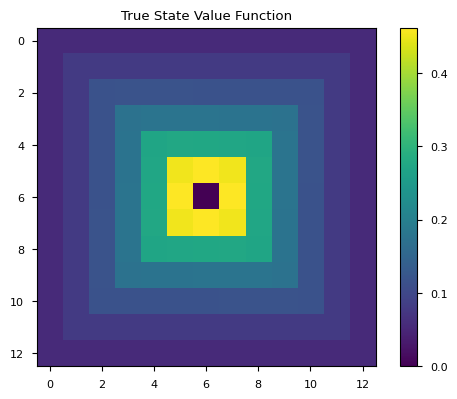

In [5]:
true_config, true_value_metrics = load_run_data("random_mc_exact/whirlpool", 'Whirlpool', 'results')
plt.imshow(true_value_metrics['value_grid'][0,5], label='True V')
plt.title('True State Value Function')
plt.colorbar()

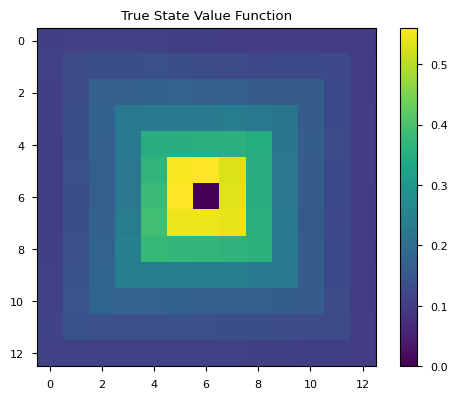

In [6]:
true_config, true_value_metrics = load_run_data("fixed_mc_exact/whirlpool", 'Whirlpool', 'results')
plt.imshow(true_value_metrics['value_grid'][0,5], label='True V')
plt.title('True State Value Function')
plt.colorbar()

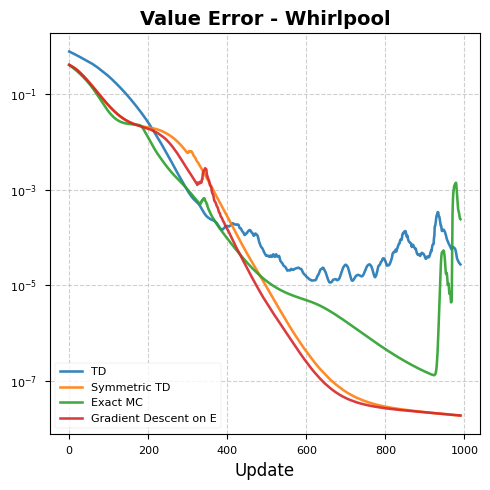

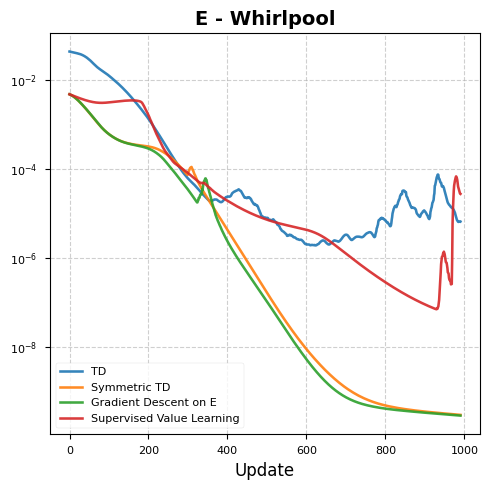

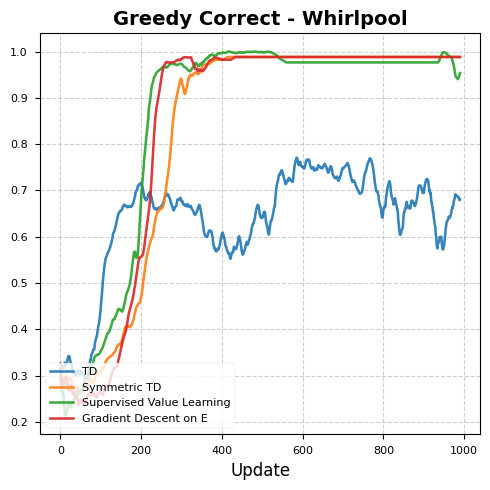

In [10]:
# stochastic_td_config, stochastic_td_metrics = load_run_data("fixed_td/7_7", 'Whirlpool', 'results')
td_config, td_metrics = load_run_data("fixed_td_exact/7_7", 'Whirlpool', 'results')
s_td_config, s_td_metrics = load_run_data("fixed_td_exact_symmetric/7_7", 'Whirlpool', 'results')
mc_config, mc_metrics = load_run_data("fixed_mc_exact/7_7", 'Whirlpool', 'results')
e_config, e_metrics = load_run_data("fixed_E_gd_exact/7_7", 'Whirlpool', 'results')

plot_experiments(
    metrics_list=[td_metrics, s_td_metrics, mc_metrics, e_metrics, ],
    run_labels=["TD", "Symmetric TD", "Exact MC", "Gradient Descent on E", ],
    title="Value Error - Whirlpool",
    metric_keys=['nn_weighted_VE'], log=True
)


plot_experiments(
    metrics_list=[td_metrics, s_td_metrics, e_metrics, mc_metrics],
    run_labels=["TD", "Symmetric TD", "Gradient Descent on E", "Supervised Value Learning"],
    title="E - Whirlpool",
    metric_keys=['E'], log=True
)


plot_experiments(
    metrics_list=[td_metrics, s_td_metrics, mc_metrics, e_metrics],
    run_labels=["TD", "Symmetric TD", "Supervised Value Learning", "Gradient Descent on E"],
    title="Greedy Correct - Whirlpool",
    metric_keys=['nn_greedy_correct']
)

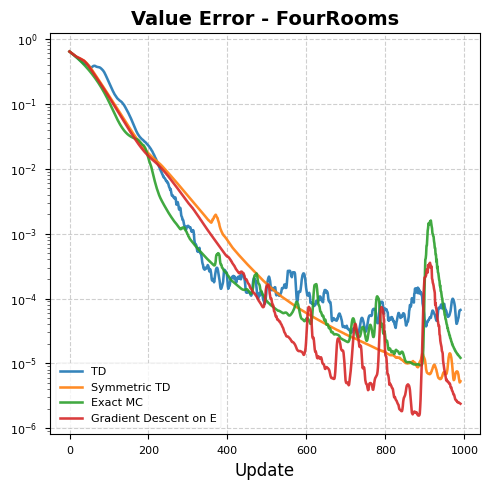

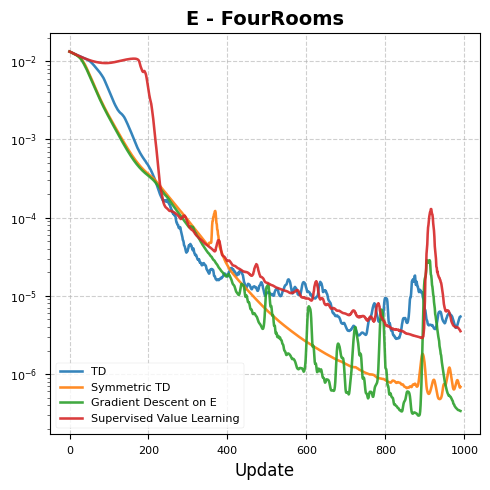

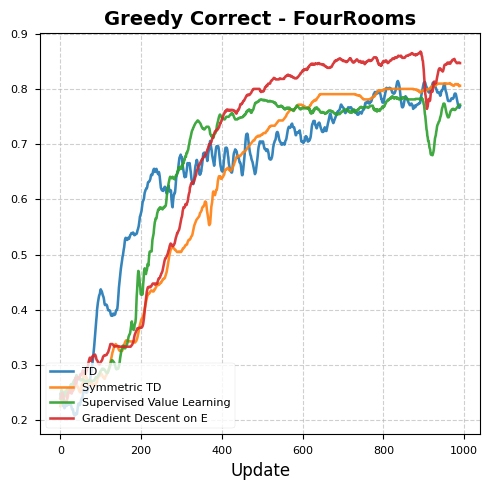

In [11]:
# stochastic_td_config, stochastic_td_metrics = load_run_data("fixed_td/7_7", 'Whirlpool', 'results')
td_config, td_metrics = load_run_data("fixed_td_exact/7_7", 'FourRooms-misc', 'results')
s_td_config, s_td_metrics = load_run_data("fixed_td_exact_symmetric/7_7", 'FourRooms-misc', 'results')
mc_config, mc_metrics = load_run_data("fixed_mc_exact/7_7", 'FourRooms-misc', 'results')
e_config, e_metrics = load_run_data("fixed_E_gd_exact/7_7", 'FourRooms-misc', 'results')

plot_experiments(
    metrics_list=[td_metrics, s_td_metrics, mc_metrics, e_metrics, ],
    run_labels=["TD", "Symmetric TD", "Exact MC", "Gradient Descent on E", ],
    title="Value Error - FourRooms",
    metric_keys=['nn_weighted_VE'], log=True
)


plot_experiments(
    metrics_list=[td_metrics, s_td_metrics, e_metrics, mc_metrics],
    run_labels=["TD", "Symmetric TD", "Gradient Descent on E", "Supervised Value Learning"],
    title="E - FourRooms",
    metric_keys=['E'], log=True
)


plot_experiments(
    metrics_list=[td_metrics, s_td_metrics, mc_metrics, e_metrics],
    run_labels=["TD", "Symmetric TD", "Supervised Value Learning", "Gradient Descent on E"],
    title="Greedy Correct - FourRooms",
    metric_keys=['nn_greedy_correct']
)

In [ ]:
import matplotlib.pyplot as plt
from core.utils import load_run_data

plt.style.use('seaborn-v0_8-paper') 

def plot_experiment_dual_axis(metrics, title, y1_keys, y2_keys, y1_labels=None, y2_labels=None, ax1_title = "Bellman Error (BE)", ax2_title = "Value Error (VE)"):
    if y1_labels is None: y1_labels = y1_keys
    if y2_labels is None: y2_labels = y2_keys
    
    fig, ax1 = plt.subplots(figsize=(6, 5))
    
    # Track all lines and labels for a single unified legend
    lines = []
    labels = []

    # Plot Primary Y-Axis (Left)
    ax1.set_xlabel("Updates (i)", fontsize=12)
    ax1.set_ylabel(ax1_title, fontsize=12, color='navy')
    ax1.tick_params(axis='y', labelcolor='navy')
    
    # Using a classic color mapping strategy to keep axes distinct
    y1_colors = ['#1f77b4', '#aec7e8'] 
    for item, label, color in zip(y1_keys, y1_labels, y1_colors):
        values = metrics[item]
        y = values.mean(0) if values.ndim > 1 else values
        line = ax1.plot(y, label=label, linewidth=2, color=color)
        lines.extend(line)
        labels.append(label)

    # Create Secondary Y-Axis (Right)
    ax2 = ax1.twinx()
    ax2.set_ylabel(ax2_title, fontsize=12, color='darkred')
    ax2.tick_params(axis='y', labelcolor='darkred')
    
    y2_colors = ['#d62728', '#ff9896']
    for item, label, color in zip(y2_keys, y2_labels, y2_colors):
        values = metrics[item]
        y = values.mean(0) if values.ndim > 1 else values
        line = ax2.plot(y, label=label, linewidth=2, color=color, linestyle='--')
        lines.extend(line)
        labels.append(label)

    # Visual tuning
    plt.title(title, fontsize=14, fontweight='bold', pad=15)
    ax1.grid(True, linestyle='--', alpha=0.4)
    
    # Merge legends from both axes into one box
    ax1.legend(lines, labels, frameon=True, loc='upper right')
    
    plt.tight_layout()
    plt.show()

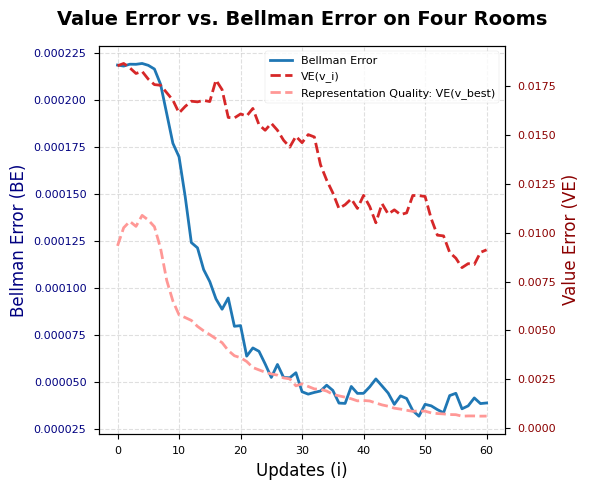

In [ ]:
td_config, td_metrics = load_run_data("random_td/no_layer_norm", 'FourRooms-misc', 'results')
plot_experiment_dual_axis(
    metrics=td_metrics, 
    title="Value Error vs. Bellman Error on Four Rooms",
    y2_keys=['nn_weighted_VE', 'VR_weighted_VE'],
    y1_keys=['nn_weighted_BE'],
    y2_labels=['VE(v_i)', 'Representation Quality: VE(v_best)'],
    y1_labels=['Bellman Error']
)

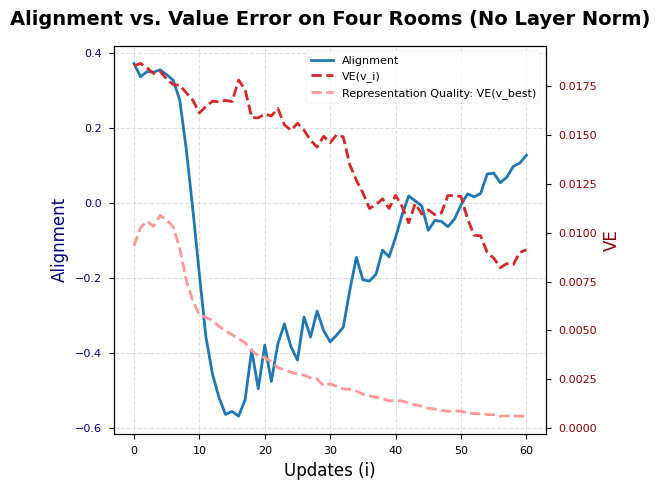

In [ ]:
plot_experiment_dual_axis(
    metrics=td_metrics, 
    title="Alignment vs. Value Error on Four Rooms (No Layer Norm)",
    y1_keys=['alignment'],
    y2_keys=['nn_weighted_VE', 'VR_weighted_VE'],
    y1_labels=['Alignment'],
    y2_labels=['VE(v_i)', 'Representation Quality: VE(v_best)'],
    ax1_title='Alignment',
    ax2_title='VE'
)

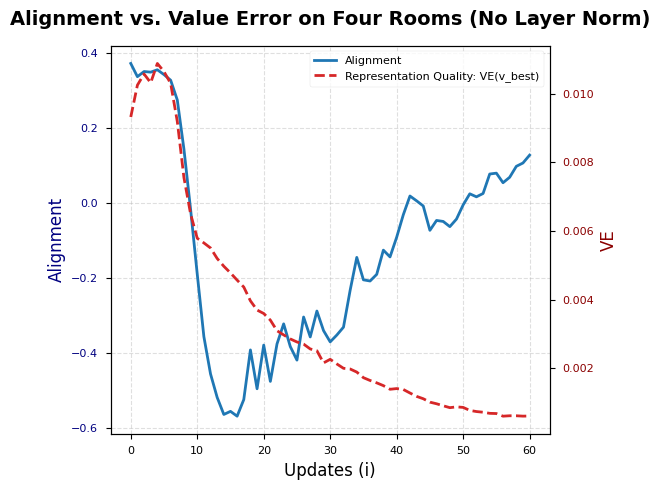

In [ ]:
plot_experiment_dual_axis(
    metrics=td_metrics, 
    title="Alignment vs. Value Error on Four Rooms (No Layer Norm)",
    y1_keys=['alignment'],
    y2_keys=['VR_weighted_VE'],
    y1_labels=['Alignment'],
    y2_labels=['Representation Quality: VE(v_best)'],
    ax1_title='Alignment',
    ax2_title='VE'
)

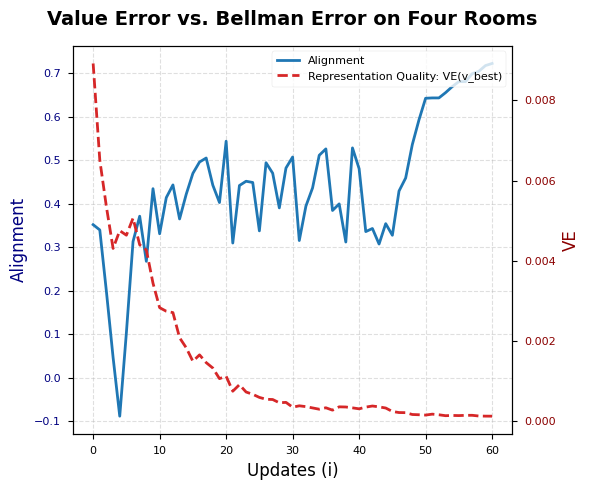

Array(0.00020236, dtype=float32)

In [ ]:
td_config, td_metrics = load_run_data("random_td/layer_norm", 'FourRooms-misc', 'results')
plot_experiment_dual_axis(
    metrics=td_metrics, 
    title="Value Error vs. Bellman Error on Four Rooms",
    y1_keys=['alignment'],
    y2_keys=['VR_weighted_VE'],
    y1_labels=['Alignment'],
    y2_labels=['Representation Quality: VE(v_best)'],
    ax1_title='Alignment',
    ax2_title='VE')
# td_metrics['VR_weighted_VE'].min()
td_metrics['nn_weighted_VE'].min()

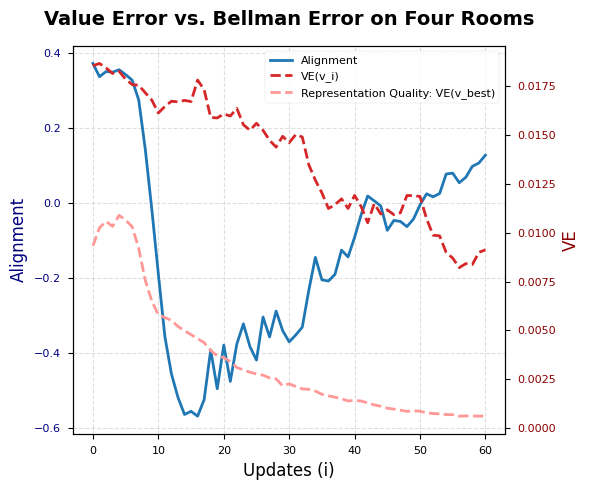

In [ ]:
td_config, td_metrics = load_run_data("random_td/no_layer_norm", 'FourRooms-misc', 'results')
plot_experiment_dual_axis(
    metrics=td_metrics, 
    title="Value Error vs. Bellman Error on Four Rooms",
    y1_keys=['alignment'],
    y2_keys=['nn_weighted_VE', 'VR_weighted_VE'],
    y1_labels=['Alignment'],
    y2_labels=['VE(v_i)', 'Representation Quality: VE(v_best)'],
    ax1_title='Alignment',
    ax2_title='VE'
)

In [ ]:
td_metrics['nn_weighted_VE'].min()

Array(0.00821082, dtype=float32)

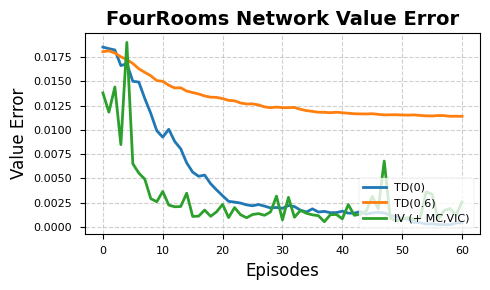

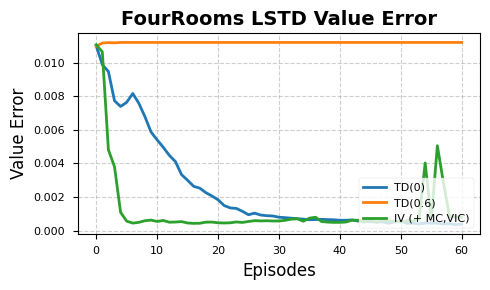

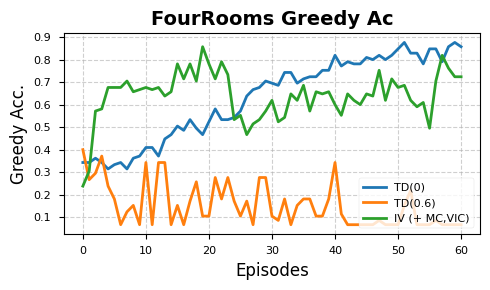

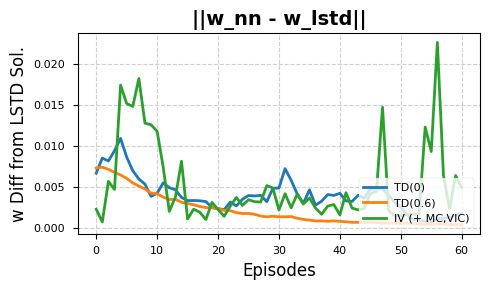

In [ ]:
# random_td_config, random_td_metrics = load_run_data("random_td/20260514_162117", 'FourRooms-misc', 'results')
random_td_config, random_td_metrics = load_run_data("random_td/20260518_170809", 'FourRooms-misc', 'results')

random_tdlambda_config, random_tdlambda_metrics = load_run_data("random_td/gae_lambda_06", 'FourRooms-misc', 'results')
random_iv_config, random_iv_metrics = load_run_data("random_iv_model_vic_mc/20260514_170412", 'FourRooms-misc', 'results')

runs = {'TD(0)': random_td_metrics['nn_weighted_VE'],'TD(0.6)': random_tdlambda_metrics['nn_weighted_VE'],'IV (+ MC,VIC)': random_iv_metrics['nn_weighted_VE']}
plot_rl_results(runs, title="FourRooms Network Value Error", y_label = "Value Error")

runs = {'TD(0)': random_td_metrics['LSTD_weighted_VE'],'TD(0.6)': random_tdlambda_metrics['LSTD_weighted_VE'], 'IV (+ MC,VIC)': random_iv_metrics['LSTD_weighted_VE']}
plot_rl_results(runs, title="FourRooms LSTD Value Error", y_label = "Value Error")

runs = {'TD(0)': random_td_metrics['nn_greedy_correct'],'TD(0.6)': random_tdlambda_metrics['nn_greedy_correct'] ,  'IV (+ MC,VIC)': random_iv_metrics['nn_greedy_correct']}
plot_rl_results(runs, title="FourRooms Greedy Ac", y_label = "Greedy Acc.")

runs = {'TD(0)': random_td_metrics['nn_lstd_diff'],'TD(0.6)': random_tdlambda_metrics['nn_lstd_diff']  , 'IV (+ MC,VIC)': random_iv_metrics['nn_lstd_diff']}
plot_rl_results(runs, title="||w_nn - w_lstd||", y_label = "w Diff from LSTD Sol.")

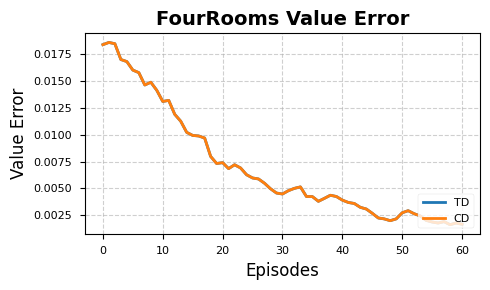

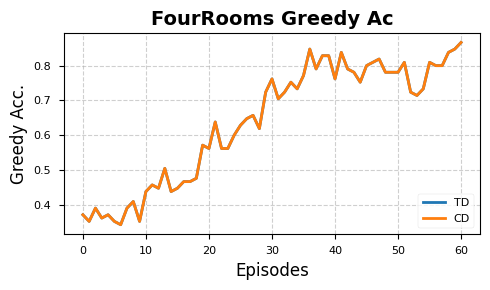

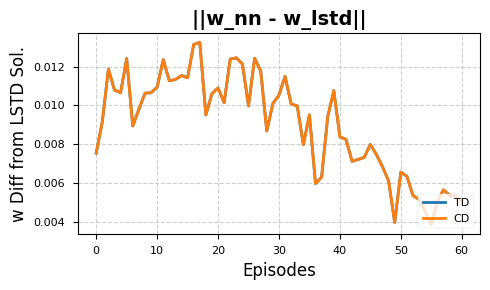

In [ ]:
td_config, td_metrics = load_run_data("random_td/no_interfering_factors", 'FourRooms-misc', 'results')
cd_config, cd_metrics = load_run_data("random_cd/no_interfering_factors", 'FourRooms-misc', 'results')
runs = {'TD': td_metrics['nn_weighted_VE'], 'CD': cd_metrics['nn_weighted_VE']}
plot_rl_results(runs, title="FourRooms Value Error", y_label = "Value Error")
runs = {'TD': td_metrics['nn_greedy_correct'], 'CD': cd_metrics['nn_greedy_correct']}
plot_rl_results(runs, title="FourRooms Greedy Ac", y_label = "Greedy Acc.")

runs = {'TD': td_metrics['nn_lstd_diff'], 'CD': cd_metrics['nn_lstd_diff']}
plot_rl_results(runs, title="||w_nn - w_lstd||", y_label = "w Diff from LSTD Sol.")

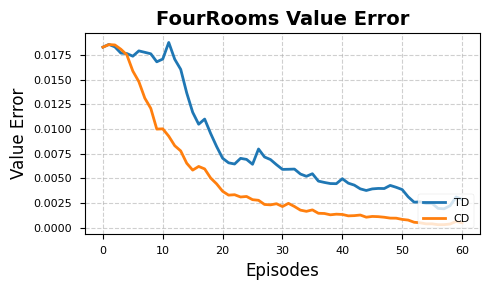

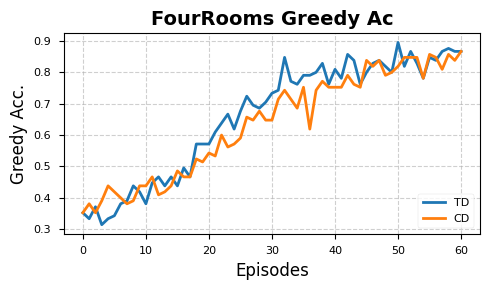

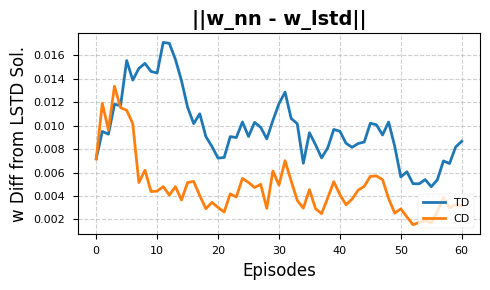

In [ ]:
td_config, td_metrics = load_run_data("random_td/20260513_163216", 'FourRooms-misc', 'results')
cd_config, cd_metrics = load_run_data("random_cd/20260513_150359", 'FourRooms-misc', 'results')
runs = {'TD': td_metrics['nn_weighted_VE'], 'CD': cd_metrics['nn_weighted_VE']}
plot_rl_results(runs, title="FourRooms Value Error", y_label = "Value Error")
runs = {'TD': td_metrics['nn_greedy_correct'], 'CD': cd_metrics['nn_greedy_correct']}
plot_rl_results(runs, title="FourRooms Greedy Ac", y_label = "Greedy Acc.")

runs = {'TD': td_metrics['nn_lstd_diff'], 'CD': cd_metrics['nn_lstd_diff']}
plot_rl_results(runs, title="||w_nn - w_lstd||", y_label = "w Diff from LSTD Sol.")

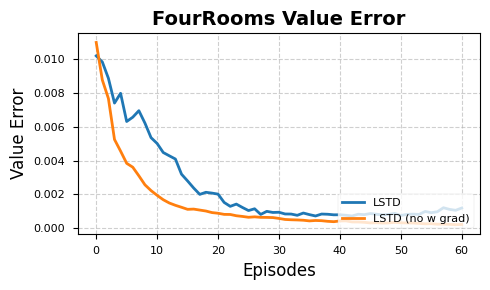

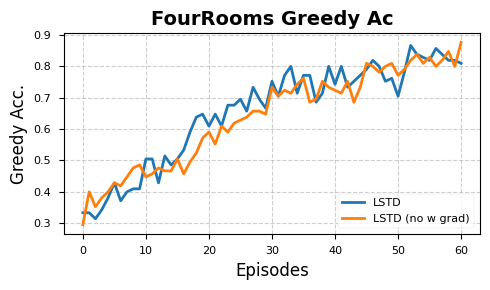

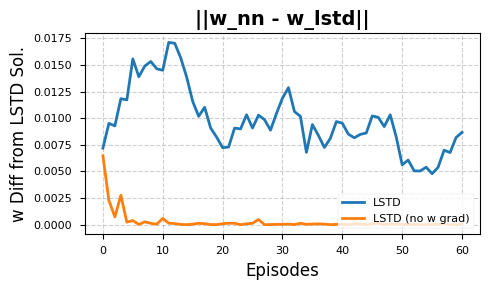

In [ ]:
lstd_config, lstd_metrics = load_run_data("random_lstd/20260511_145036", 'FourRooms-misc', 'results')
lstd_cd_config, lstd_cd_metrics = load_run_data("random_lstd/20260513_154513", 'FourRooms-misc', 'results')
lstd_nw_config, lstd_nw_metrics = load_run_data("random_lstd/20260513_160625", 'FourRooms-misc', 'results')

runs = {'LSTD': td_metrics['LSTD_weighted_VE'], 'LSTD (no w grad)': lstd_nw_metrics['LSTD_weighted_VE']}
plot_rl_results(runs, title="FourRooms Value Error", y_label = "Value Error")
runs = {'LSTD': td_metrics['LSTD_greedy_correct'], 'LSTD (no w grad)': lstd_nw_metrics['LSTD_greedy_correct']}
plot_rl_results(runs, title="FourRooms Greedy Ac", y_label = "Greedy Acc.")

runs = {'LSTD': td_metrics['nn_lstd_diff'], 'LSTD (no w grad)': lstd_nw_metrics['nn_lstd_diff']}
plot_rl_results(runs, title="||w_nn - w_lstd||", y_label = "w Diff from LSTD Sol.")

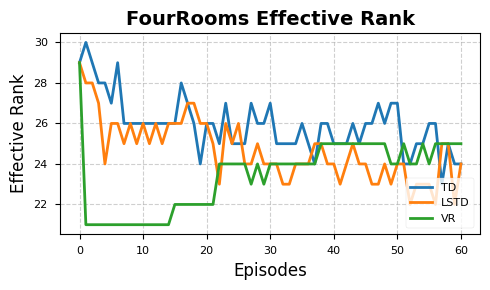

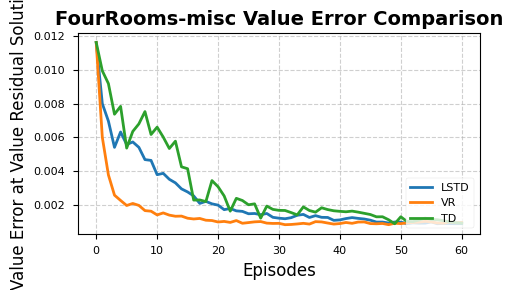

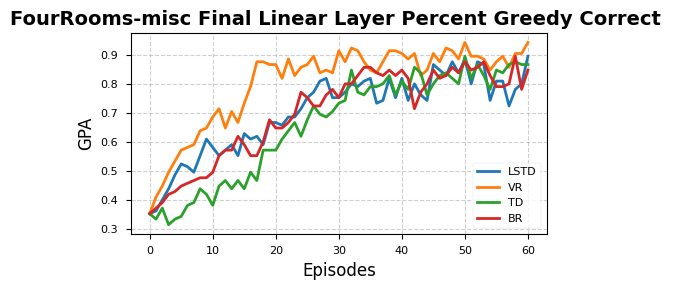

In [ ]:
td_config, td_metrics = load_run_data("random_td/20260511_144250", 'FourRooms-misc', 'results')
config, lstd_metrics = load_run_data("random_lstd/20260511_145036", 'FourRooms-misc', 'results')
config, vr_metrics = load_run_data("random_vr/20260511_145817", 'FourRooms-misc', 'results')
config, br_metrics = load_run_data("random_br/20260511_145516", 'FourRooms-misc', 'results')

runs = {
    "TD": td_metrics['effective_rank'],
    "LSTD": lstd_metrics['effective_rank'],
    "VR": vr_metrics['effective_rank'],
    # "BR": br_metrics['effective_rank']
}
plot_rl_results(runs, title="FourRooms Effective Rank", y_label = "Effective Rank")

runs = {
    "LSTD": lstd_metrics['VR_uniform_VE'],
    "VR": vr_metrics['VR_uniform_VE'],
    "TD": td_metrics['VR_uniform_VE'],
    # "BR": br_metrics['VR_uniform_VE']
}

plot_rl_results(runs, title="FourRooms-misc Value Error Comparison", y_label = "Value Error at Value Residual Solution")

runs = {
    "LSTD": lstd_metrics['nn_greedy_correct'],
    "VR": vr_metrics['nn_greedy_correct'],
    "TD": td_metrics['nn_greedy_correct'],
    "BR": br_metrics['nn_greedy_correct']
}

plot_rl_results(runs, title="FourRooms-misc Final Linear Layer Percent Greedy Correct ", y_label = "GPA")

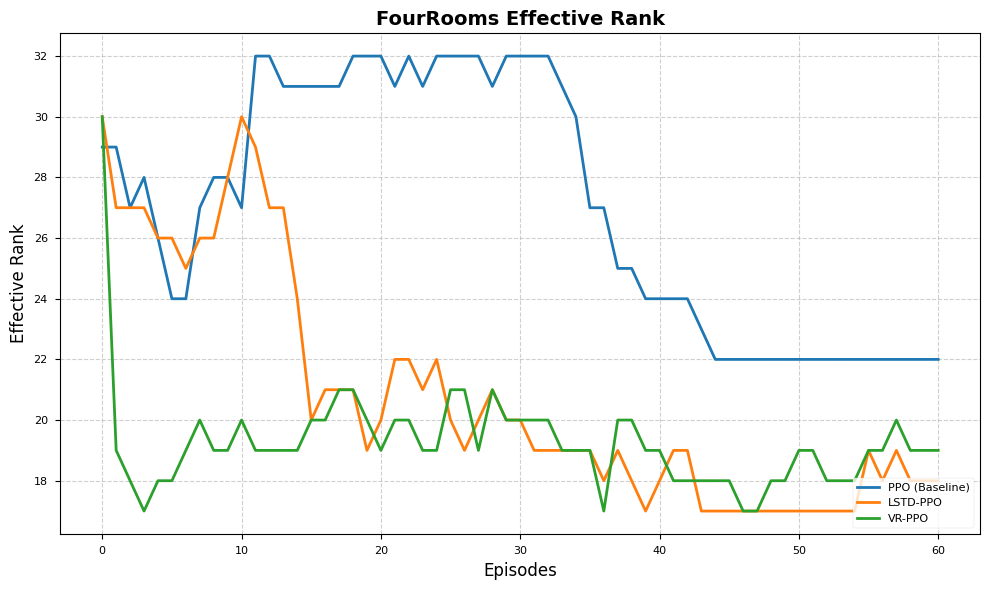

In [ ]:

runs = {
    "PPO (Baseline)": metrics['effective_rank'],
    "LSTD-PPO": lstd_ppo_metrics['effective_rank'],
    "VR-PPO": vr_ppo_metrics['effective_rank']
}

plot_rl_results(runs, title="FourRooms Effective Rank", y_label = "Effective Rank")

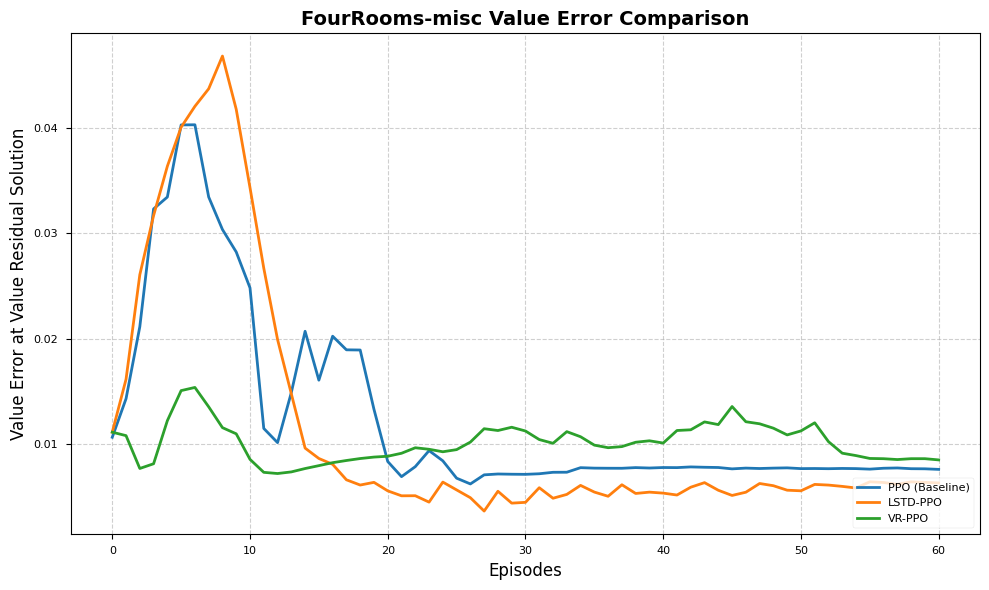

In [ ]:
runs = {
    "PPO (Baseline)": metrics['VR_uniform_VE'],
    "LSTD-PPO": lstd_ppo_metrics['VR_uniform_VE'],
    "VR-PPO": vr_ppo_metrics['VR_uniform_VE']
}

plot_rl_results(runs, title="FourRooms-misc Value Error Comparison", y_label = "Value Error at Value Residual Solution")


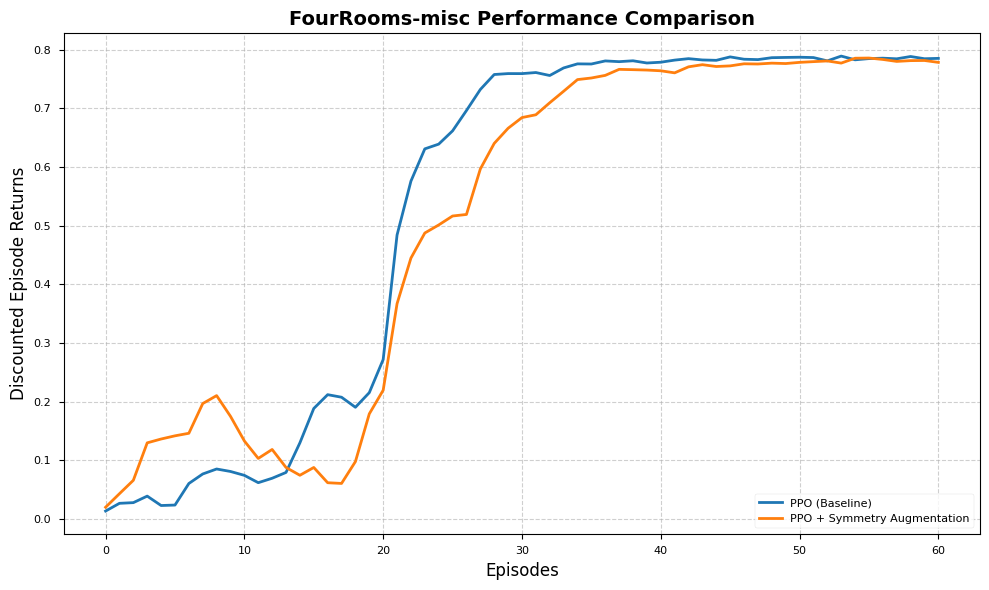

In [ ]:
# results/ppo_symmetry_augmentation/20260511_161729/FourRooms-misc/Weightedconfig


ppoconfig, metrics = load_run_data("ppo/20260510_092335", 'FourRooms-misc', 'results')
ppoconfig, symmetrics = load_run_data("ppo_symmetry_augmentation/20260511_161729", 'FourRooms-misc', 'results')

runs = {
    "PPO (Baseline)": metrics['returned_discounted_episode_returns'],
    "PPO + Symmetry Augmentation": symmetrics['returned_discounted_episode_returns']
    
}

plot_rl_results(runs, title="FourRooms-misc Performance Comparison")